# Учимся работе с данными - от загрузки до моделирования

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Настройки визуализации
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

### 1. Загрузка данных

Скачайте датасет с Kaggle по [ссылке](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data) и поместите файл `data.csv` в папку `homework_09/data/`.

In [2]:
df = pd.read_csv('data.csv')
print("Размер данных:", df.shape)
df.head()

Размер данных: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Базовые статистики и распределения

In [3]:
# Удаляем id
if 'id' in df.columns:
    df = df.drop('id', axis=1)

In [4]:
print("Распределение диагнозов:")
print(df['diagnosis'].value_counts())
print("Проценты:")
print(df['diagnosis'].value_counts(normalize=True) * 100)

Распределение диагнозов:
diagnosis
B    357
M    212
Name: count, dtype: int64
Проценты:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [5]:
print("Описательная статистика:")
df.describe()

Описательная статистика:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


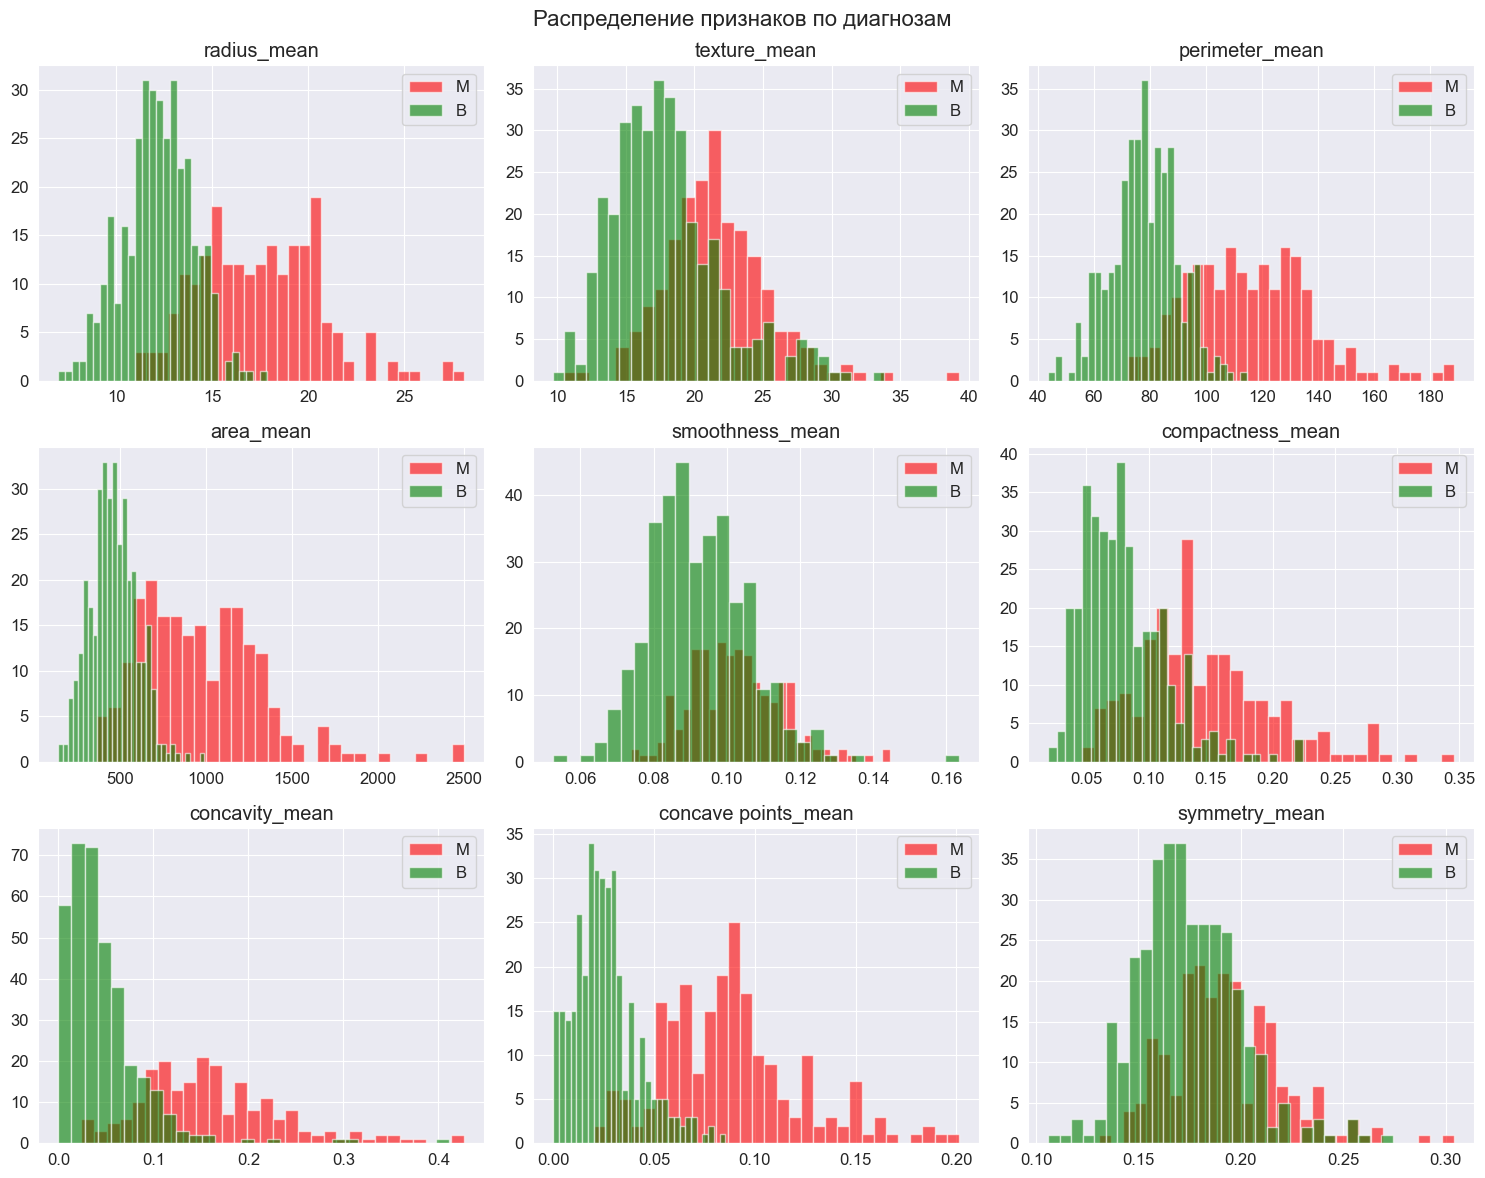

In [6]:
# Все колонки, кроме diagnosis
features = df.columns[df.columns != 'diagnosis'].tolist()
# Для злокачественных - красный, для доброкачественных - зеленый
colors = {'M': 'red', 'B': 'green'}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features[:9]):
    for diagnosis in ['M', 'B']:
        subset = df[df['diagnosis'] == diagnosis]
        axes[i].hist(subset[feature], bins=30, alpha=0.6,
                     label=f'{diagnosis}', color=colors[diagnosis])
    axes[i].set_title(feature)
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('Распределение признаков по диагнозам', fontsize=16)
plt.tight_layout()
plt.show()

### 3. Корреляционный анализ и heatmap

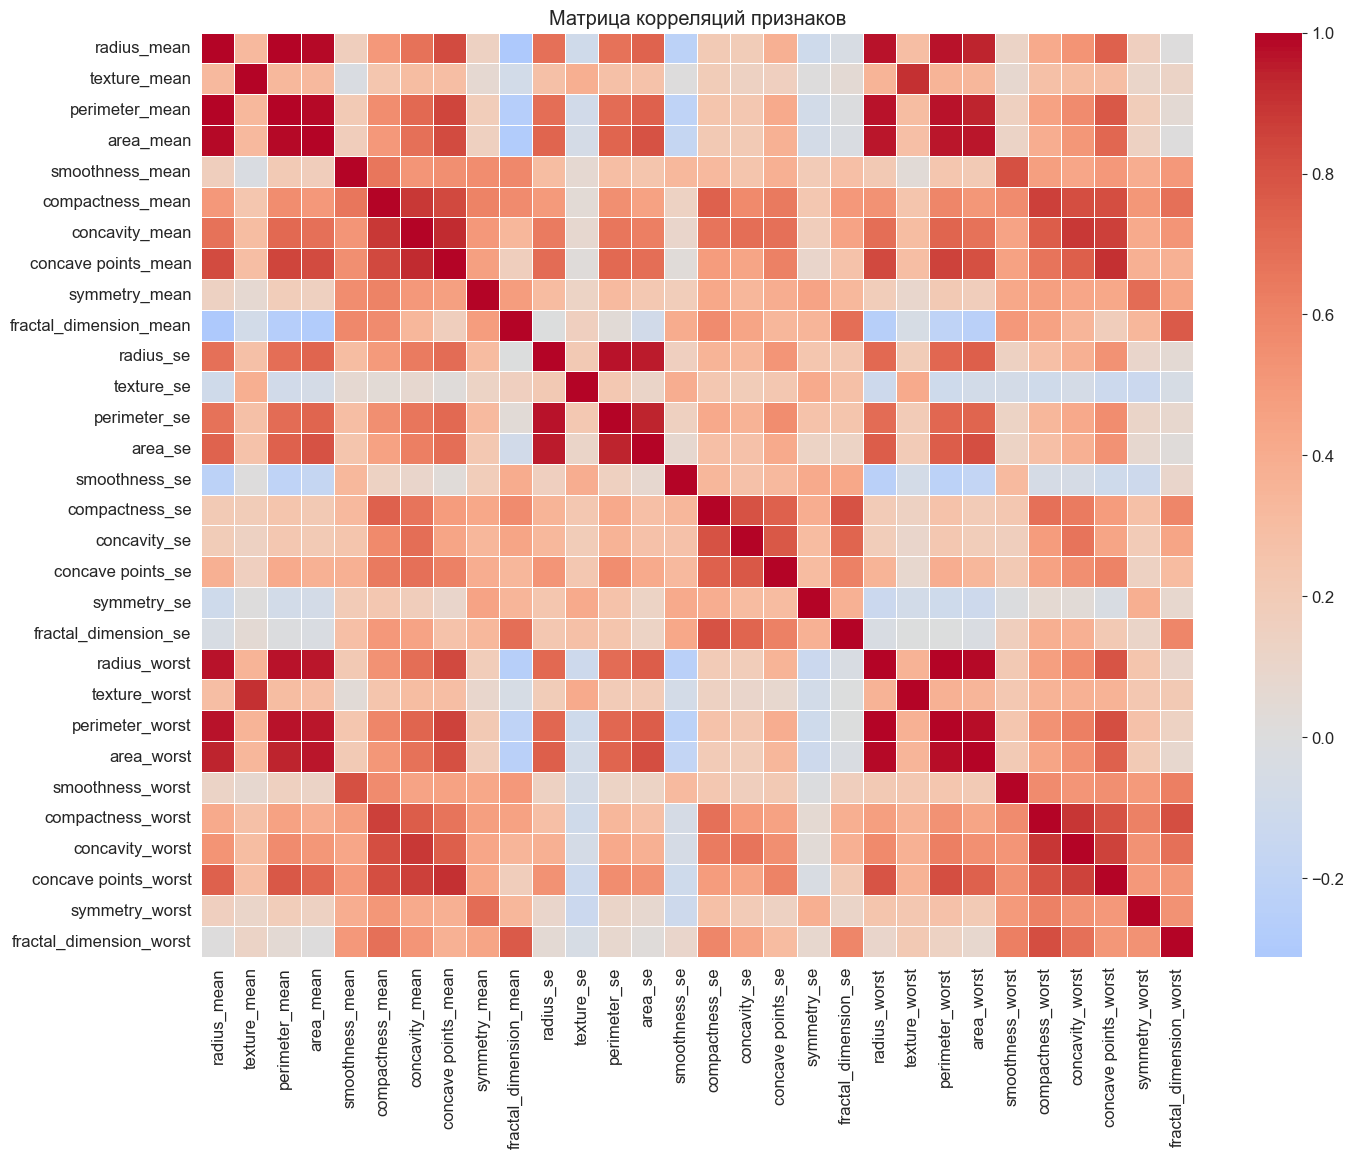

In [7]:
# Выбираем только числовые колонки для корреляции
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# Строим heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Матрица корреляций признаков')
plt.show()

In [8]:
# Пары признаков с корреляцией > 0.85
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Пары признаков с высокой корреляцией (> 0.85):")
for pair in high_corr:
    print(f"{pair[0]} и {pair[1]}: {pair[2]:.2f}")

Пары признаков с высокой корреляцией (> 0.85):
perimeter_mean и radius_mean: 1.00
area_mean и radius_mean: 0.99
area_mean и perimeter_mean: 0.99
concavity_mean и compactness_mean: 0.88
concave points_mean и perimeter_mean: 0.85
concave points_mean и concavity_mean: 0.92
perimeter_se и radius_se: 0.97
area_se и radius_se: 0.95
area_se и perimeter_se: 0.94
radius_worst и radius_mean: 0.97
radius_worst и perimeter_mean: 0.97
radius_worst и area_mean: 0.96
texture_worst и texture_mean: 0.91
perimeter_worst и radius_mean: 0.97
perimeter_worst и perimeter_mean: 0.97
perimeter_worst и area_mean: 0.96
perimeter_worst и concave points_mean: 0.86
perimeter_worst и radius_worst: 0.99
area_worst и radius_mean: 0.94
area_worst и perimeter_mean: 0.94
area_worst и area_mean: 0.96
area_worst и radius_worst: 0.98
area_worst и perimeter_worst: 0.98
compactness_worst и compactness_mean: 0.87
concavity_worst и concavity_mean: 0.88
concavity_worst и compactness_worst: 0.89
concave points_worst и concavity_

In [9]:
# radius_mean, perimeter_mean, area_mean коррелируют почти с коэффициентом 1 (чем больше радиус, тем больше периметр и площадь), но есть и другие пары

### 4. Scatterplot для сильно скоррелированных признаков

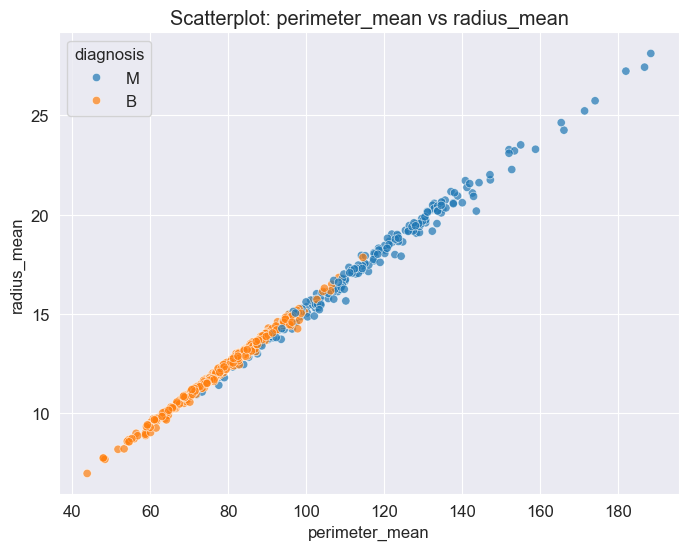

In [10]:
if high_corr:
    feat1, feat2, _ = high_corr[0]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=feat1, y=feat2, hue='diagnosis', alpha=0.7)
    plt.title(f'Scatterplot: {feat1} vs {feat2}')
    plt.show()

In [11]:
# Да, зависимость линейная, т.к. точки выстраиваются почти по прямой линии

### 5. Boxplots для выявления разделяющих признаков

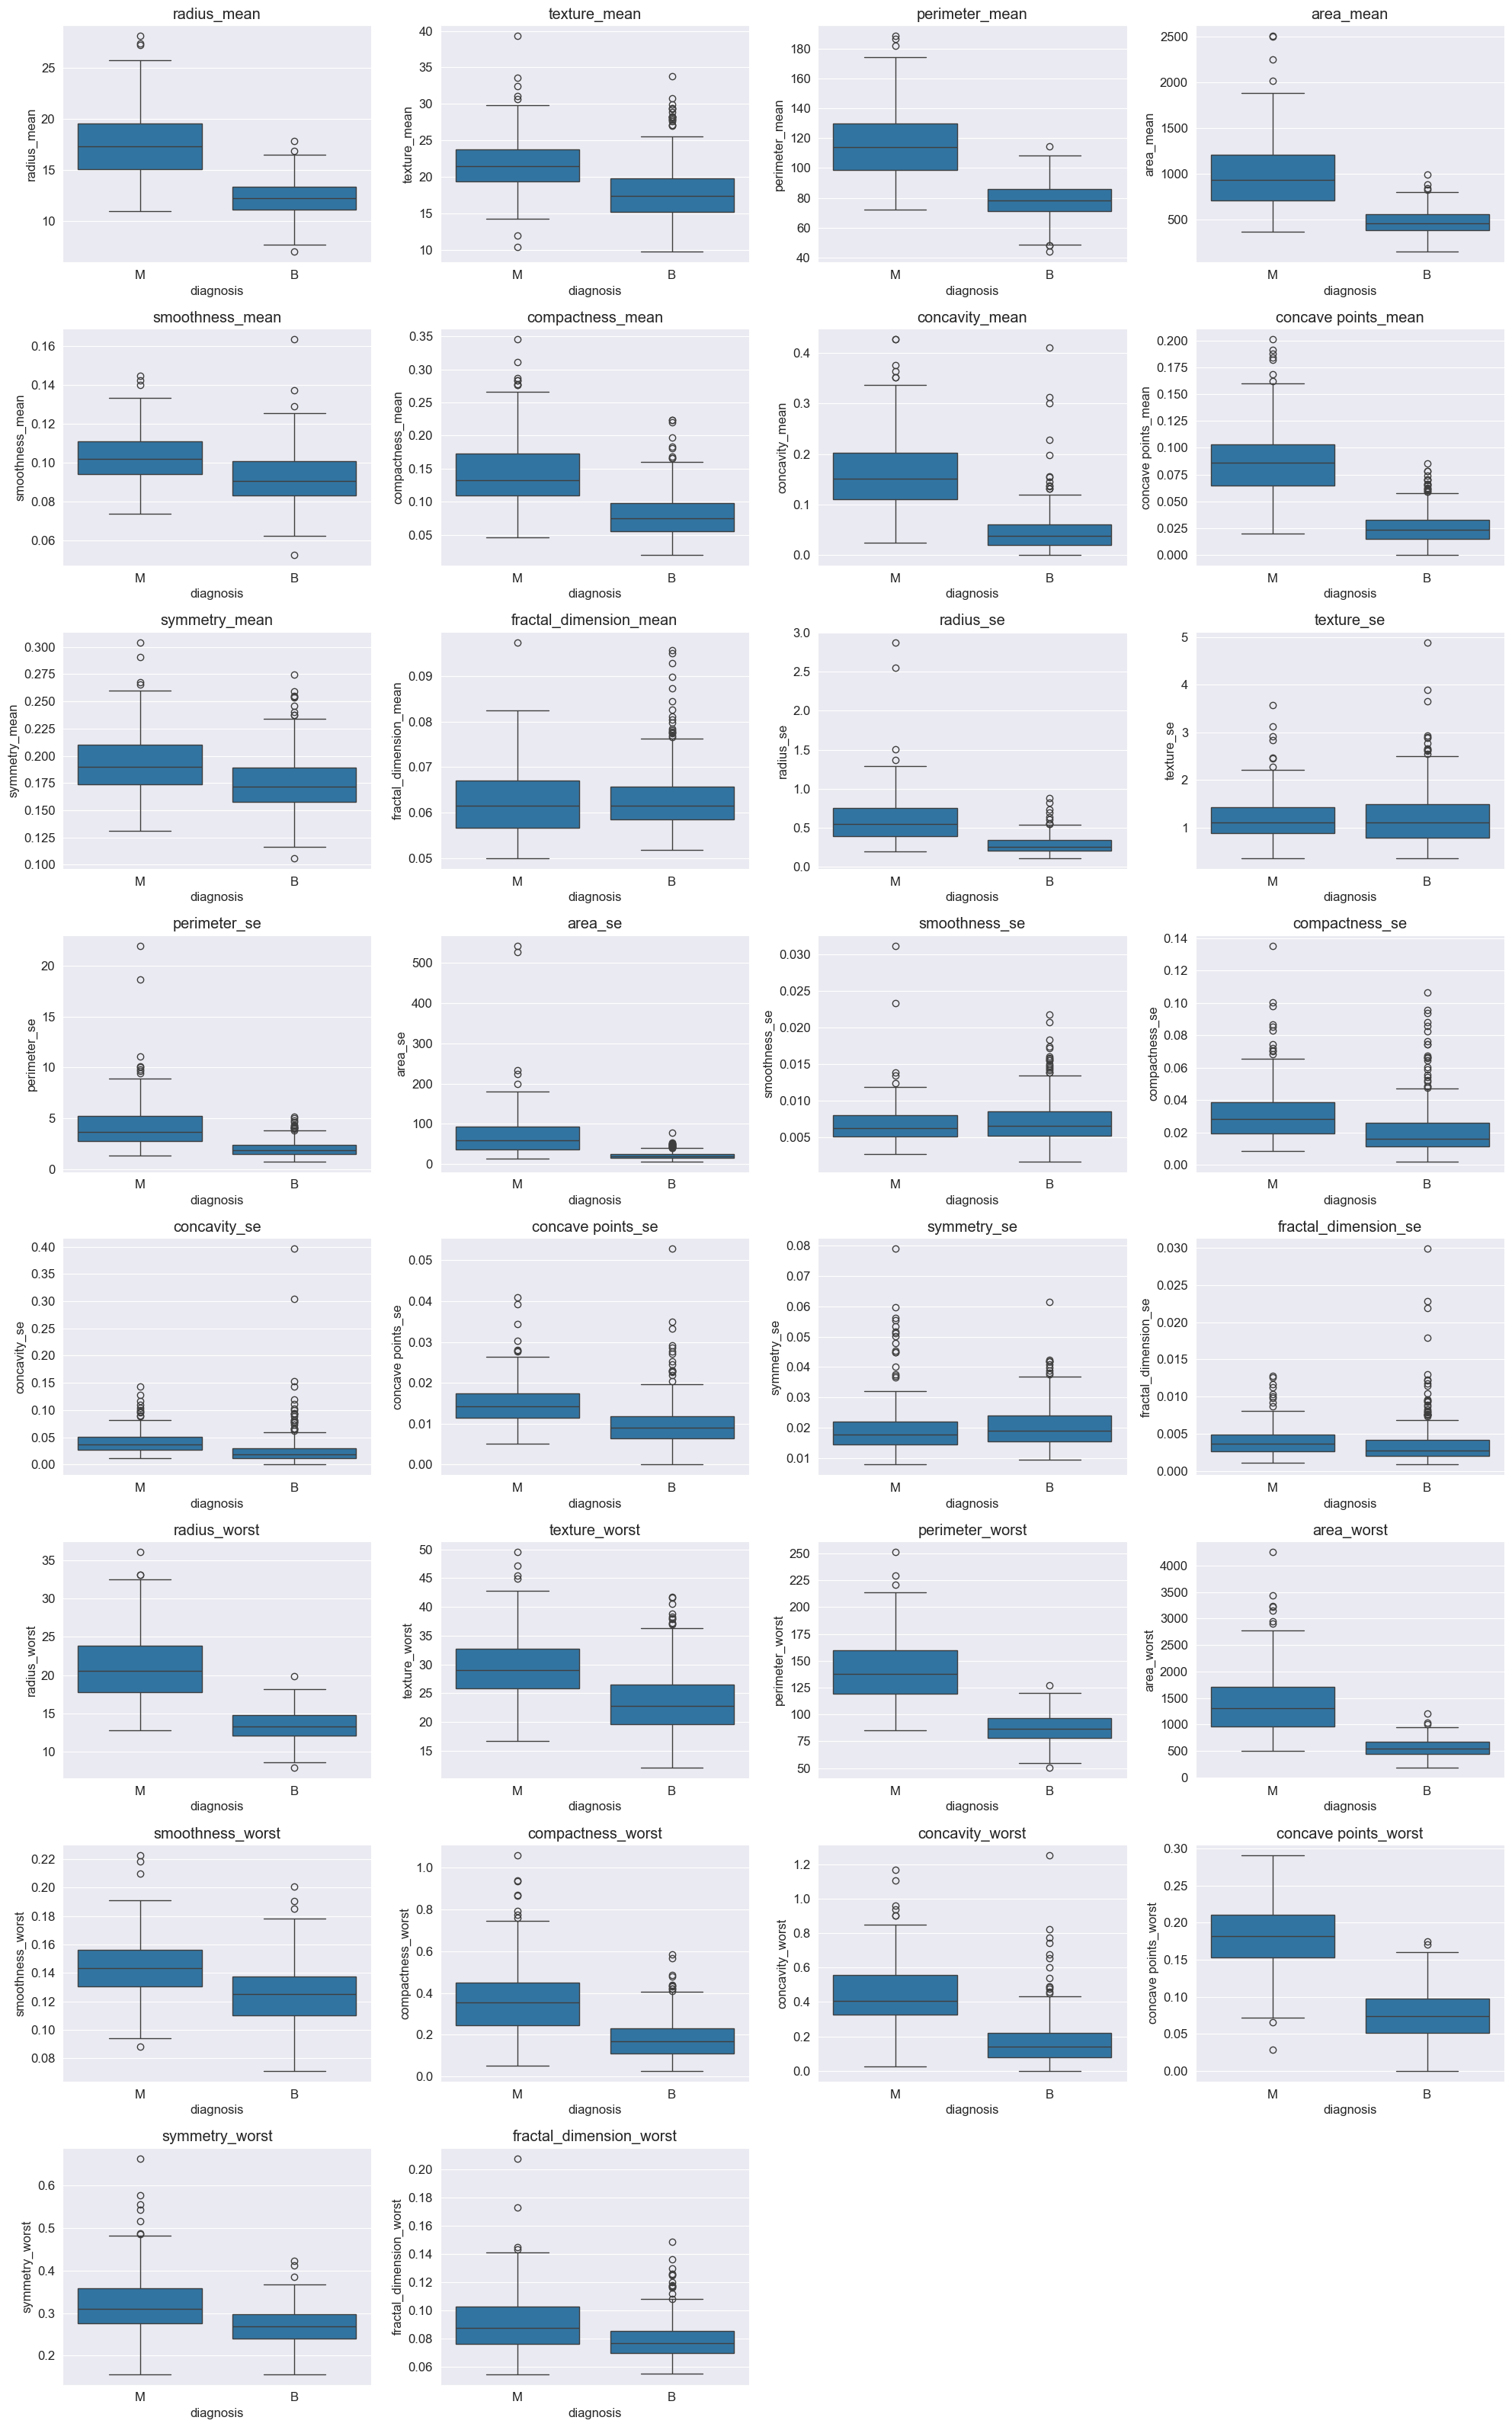

In [12]:
features = [col for col in df.columns if col not in ['diagnosis']]

n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[i])
    axes[i].set_title(feature)

for i in range(len(features), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

In [13]:
# Удобнее отделить злокачественные новообразования от доброкачественных по radius_worst, perimeter_worst, area_worst,
# concavity_worst, concave points_worst

## Часть 2: Моделирование при помощи kNN

### 2.1 Предобработка данных и разделение на train/test

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'B': 0, 'M': 1})

# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (398, 30)
Размер тестовой выборки: (171, 30)


### 2.2 Стандартизация признаков

**Почему нужна стандартизация?**
kNN основан на вычислении расстояний между точками. Если признаки имеют разные масштабы (например, area_mean от 100 до 2000, а smoothness_mean от 0.05 до 0.15), то признаки с большими значениями будут доминировать при вычислении расстояния, что исказит работу алгоритма. Стандартизация приводит все признаки к одному масштабу (среднее 0, стандартное отклонение 1).

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### 2.3 Модель kNN без настройки (k=5 по умолчанию)

              precision    recall  f1-score   support

           B       0.95      1.00      0.97       107
           M       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171

ROC-AUC: 0.9882


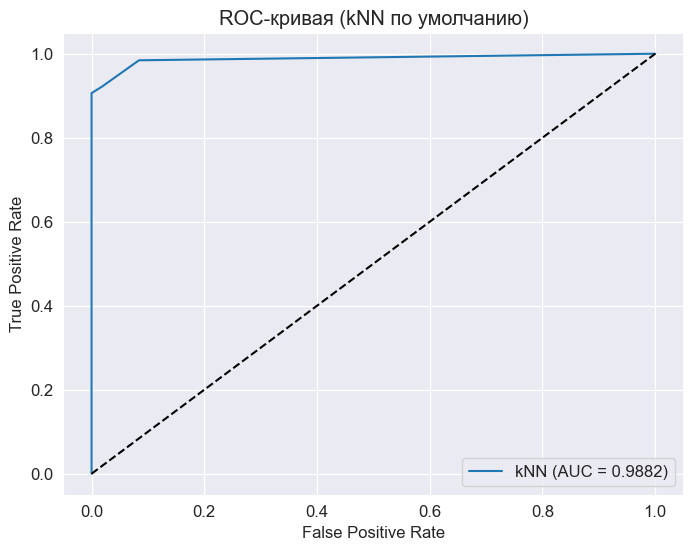

In [16]:
# Обучение модели
knn_default = KNeighborsClassifier()
knn_default.fit(X_train_scaled, y_train)
y_pred_default = knn_default.predict(X_test_scaled)
y_proba_default = knn_default.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_default, target_names=['B', 'M']))

fpr_default, tpr_default, _ = roc_curve(y_test, y_proba_default)
roc_auc_default = auc(fpr_default, tpr_default)
print(f"ROC-AUC: {roc_auc_default:.4f}")

# Построение ROC-кривой
plt.figure(figsize=(8, 6))
plt.plot(fpr_default, tpr_default, label=f'kNN (AUC = {roc_auc_default:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (kNN по умолчанию)')
plt.legend()
plt.show()

### 2.4 Настройка числа соседей k на кросс-валидации

Лучшее значение k: 10
Лучшее ROC-AUC на кросс-валидации: 0.9893


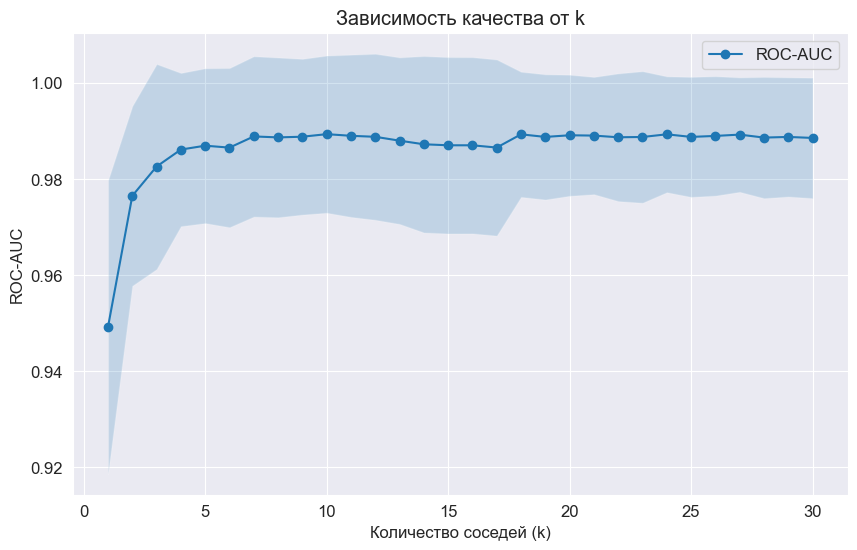

In [17]:
# Подбор параметра k
param_grid = {'n_neighbors': range(1, 31)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

print(f"Лучшее значение k: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшее ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(results['param_n_neighbors'], results['mean_test_score'], 'o-', label='ROC-AUC')
plt.fill_between(results['param_n_neighbors'], 
                 results['mean_test_score'] - results['std_test_score'],
                 results['mean_test_score'] + results['std_test_score'], alpha=0.2)
plt.xlabel('Количество соседей (k)')
plt.ylabel('ROC-AUC')
plt.title('Зависимость качества от k')
plt.legend()
plt.show()

              precision    recall  f1-score   support

           B       0.94      0.99      0.96       107
           M       0.98      0.89      0.93        64

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

ROC-AUC: 0.9885


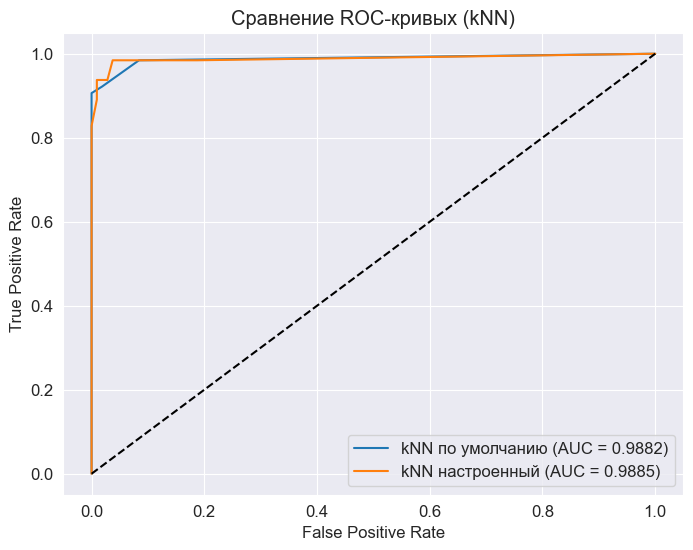

In [19]:
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)
y_proba_best = best_knn.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_best, target_names=['B', 'M']))

fpr_best, tpr_best, _ = roc_curve(y_test, y_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)
print(f"ROC-AUC: {roc_auc_best:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_default, tpr_default, label=f'kNN по умолчанию (AUC = {roc_auc_default:.4f})')
plt.plot(fpr_best, tpr_best, label=f'kNN настроенный (AUC = {roc_auc_best:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых (kNN)')
plt.legend()
plt.show()

In [20]:
# Настройка параметра k позволила улучшить качество модели. Лучшее значение k обычно находится в диапазоне 5-15
# Модель показывает отличные результаты (AUC > 0.99).

## Часть 3 (Бонус): Логистическая регрессия

### 3.1 Удаление высоко коррелированных признаков

In [22]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# Удаляем признаки с корреляцией > 0.85
def remove_high_corr_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    return X.drop(columns=to_drop), to_drop

X_reduced, dropped_cols = remove_high_corr_features(X_train)
print(f"Удаленные признаки: {dropped_cols}")
print(f"Оставшиеся признаки: {X_reduced.shape[1]}")

X_test_reduced = X_test.drop(columns=dropped_cols, errors='ignore')

scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_reduced)
X_test_lr = scaler_lr.transform(X_test_reduced)

Удаленные признаки: ['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']
Оставшиеся признаки: 17


### 3.2 Логистическая регрессия без настройки

              precision    recall  f1-score   support

           B       0.96      1.00      0.98       107
           M       1.00      0.94      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171

ROC-AUC: 0.9972


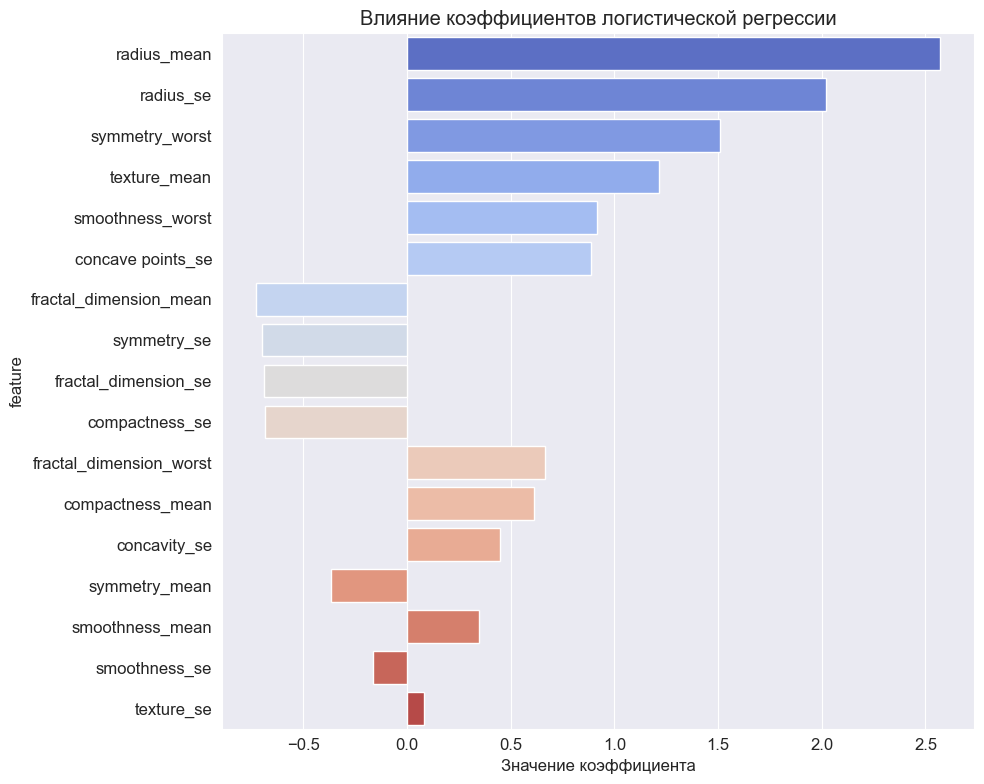

In [25]:
lr_default = LogisticRegression(random_state=42)
lr_default.fit(X_train_lr, y_train)
y_pred_lr_default = lr_default.predict(X_test_lr)
y_proba_lr_default = lr_default.predict_proba(X_test_lr)[:, 1]

print(classification_report(y_test, y_pred_lr_default, target_names=['B', 'M']))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr_default)
roc_auc_lr = auc(fpr_lr, tpr_lr)
print(f"ROC-AUC: {roc_auc_lr:.4f}")

coefs = pd.DataFrame({
    'feature': X_reduced.columns,
    'coef': lr_default.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coefs, y='feature', x='coef', palette='coolwarm')
plt.title('Влияние коэффициентов логистической регрессии')
plt.xlabel('Значение коэффициента')
plt.tight_layout()
plt.show()

### 3.3 Настройка параметра регуляризации C (LogisticRegressionCV)

Лучшее значение C: 0.0464
              precision    recall  f1-score   support

           B       0.92      0.99      0.95       107
           M       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171

ROC-AUC: 0.9956


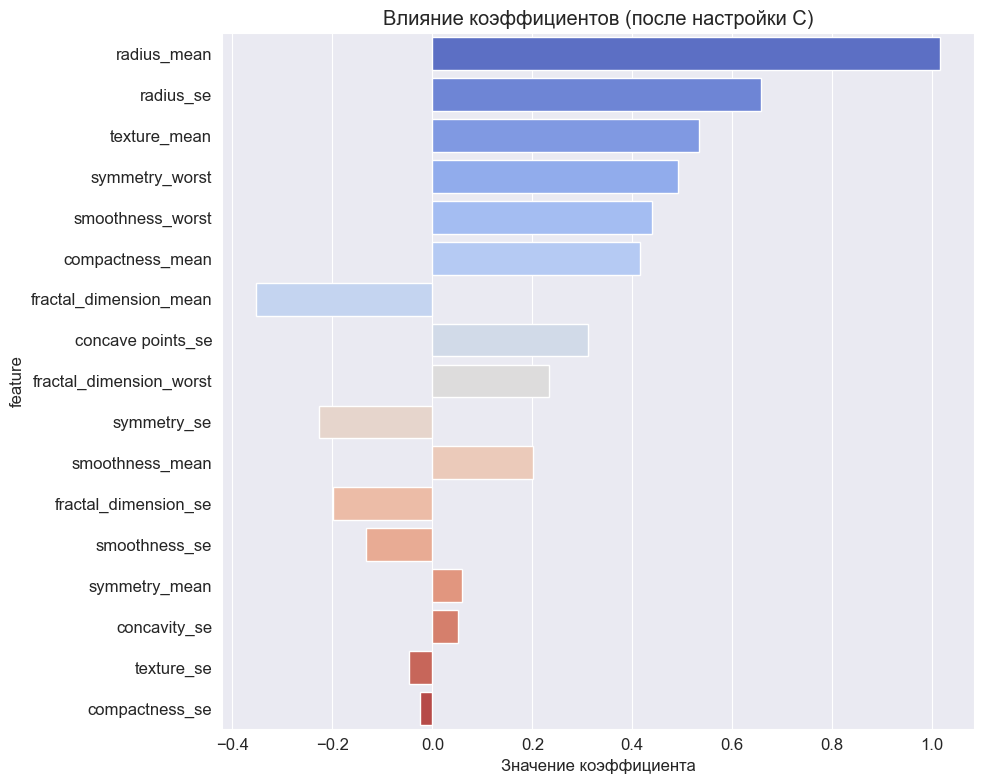

In [26]:
lr_cv = LogisticRegressionCV(Cs=10, cv=5, random_state=42, scoring='roc_auc')
lr_cv.fit(X_train_lr, y_train)
print(f"Лучшее значение C: {lr_cv.C_[0]:.4f}")

y_pred_lr_cv = lr_cv.predict(X_test_lr)
y_proba_lr_cv = lr_cv.predict_proba(X_test_lr)[:, 1]
print(classification_report(y_test, y_pred_lr_cv, target_names=['B', 'M']))

fpr_lr_cv, tpr_lr_cv, _ = roc_curve(y_test, y_proba_lr_cv)
roc_auc_lr_cv = auc(fpr_lr_cv, tpr_lr_cv)
print(f"ROC-AUC: {roc_auc_lr_cv:.4f}")

coefs_cv = pd.DataFrame({
    'feature': X_reduced.columns,
    'coef': lr_cv.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coefs_cv, y='feature', x='coef', palette='coolwarm')
plt.title('Влияние коэффициентов (после настройки C)')
plt.xlabel('Значение коэффициента')
plt.tight_layout()
plt.show()

### 3.4 Сравнение моделей и выводы

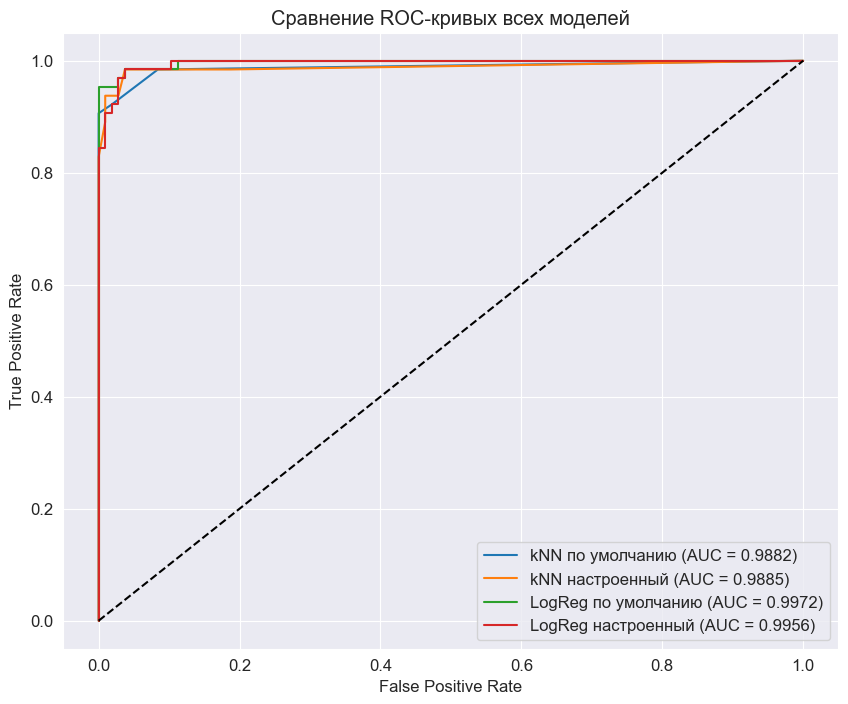

In [29]:
# Сравнение ROC-кривых всех моделей
plt.figure(figsize=(10, 8))
plt.plot(fpr_default, tpr_default, label=f'kNN по умолчанию (AUC = {roc_auc_default:.4f})')
plt.plot(fpr_best, tpr_best, label=f'kNN настроенный (AUC = {roc_auc_best:.4f})')
plt.plot(fpr_lr, tpr_lr, label=f'LogReg по умолчанию (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_lr_cv, tpr_lr_cv, label=f'LogReg настроенный (AUC = {roc_auc_lr_cv:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых всех моделей')
plt.legend()
plt.show()

In [ ]:
# Какая из двух настроенных моделей, kNN или логистическая регрессия, оказалась в итоге лучше?
# Лучше оказалась LogReg по умолчанию (AUC=0.9972), однако разница между моделями незначительна, что говорит о хорошей разделимости классов.
# kNN после настройки достиг ROC-AUC ~ 0.99, также и логистическая регрессия также показала ROC-AUC > 0.99
# kNN не требует предположений о распределении данных, хорошо работает с нелинейными границами и легко интерпретируется по методу ближайших соседей
# Логистическая регрессия дает интерпретируемость (коэффициенты показывают влияние признаков, быстрее работает на больших данных, менее чувствительна к выбросам, поэтому она лучше в этой задаче